**Business Problem**

A global ecommerce company operating across multiple regions manages end-to-end order fulfillment , including shipping and delivery, for products like sporting goods. The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late deliveries and unpredictable order profitability.

**Desired Outcome**

The goal is to analyze delivery operations,identify bottlenecks, and build a predictive system to reduce delays,optimize shipping decisions and improve overall profitability and efficiency.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
viridis_colors=cm.viridis(np.linspace(0,1,5))
primary_color=viridis_colors[0]
secondary_color=viridis_colors[1]
accent_color=viridis_colors[2]
danger_color='#800000'
neutral_color=viridis_colors[4]
custom_palette=viridis_colors

In [3]:
df=pd.read_csv('DataCoSupplyChainDataset.csv',encoding='latin-1')

In [4]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

## Exploratory Data Analysis (EDA)

In [5]:
print('rows,columns:',df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplicates:',df.duplicated().sum())
print('\nMissing values Top 20:')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows,columns: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Prod

In [6]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


### Data Cleaning

In [7]:
# The goal is to analyze delivery process and identify the bottlenecks , improve the productivity and efficiency of delivery. 
# We can remove columns which are not helpful for our analysis.

# Going through first 20 columns
first_20=list(df.columns[:20])
print(first_20)
print('\n')
df[first_20].head()

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode']




,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0


In [8]:
# From the first 20 columns - the below columns are redundant, because they dont have anything to do with delivery delay.
"""
1. Category Id
2.Category Name
3.Customer Email
4.Customer Fname
5.Customer Id
6.Customer Lname
7.Customer Password
8.Customer Segment
9.Customer Street
10.Customer Zipcode
"""

'\n1. Category Id\n2.Category Name\n3.Customer Email\n4.Customer Fname\n5.Customer Id\n6.Customer Lname\n7.Customer Password\n8.Customer Segment\n9.Customer Street\n10.Customer Zipcode\n'

In [9]:
# for the next 20 columns
second_20=list(df.columns[20:40])
print(second_20)
print('\n')
df[second_20].head()

['Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order']




,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order
0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000
1,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996
2,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999
3,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001
4,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007


In [10]:
# for the remaining columns
remaining_cols=list(df.columns[40:])
print(remaining_cols)
print('\n')
df[remaining_cols].head()


['Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode']




,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [11]:
"""
1. Category Id
2.Category Name
3.Customer Email
4.Customer Fname
5.Customer Id
6.Customer Lname
7.Customer Password
8.Customer Segment
9.Customer Street
10.Customer Zipcode
11. Department Id
12. Department Name
13. Latitude
14. Longitude
15. Order City
16.Order Customer Id
17.Order Id
18.Order Item Cardprod Id
19.Order Item Discount
20.Order Item Discount Rate
21.Order Item Id
22.Order Item Product Price
23.Order Item Profit Ratio
24.Order Item Quantity
25.Order Item Total
26.Order Profit Per Order
25. Order State
26. Order Zipcode
27. Product Card Id
28. Product Category Id
29. Product Description
30. Product Image
31. Product Name
32. Product Price
33. Product Status
   
"""


'\n1. Category Id\n2.Category Name\n3.Customer Email\n4.Customer Fname\n5.Customer Id\n6.Customer Lname\n7.Customer Password\n8.Customer Segment\n9.Customer Street\n10.Customer Zipcode\n11. Department Id\n12. Department Name\n13. Latitude\n14. Longitude\n15. Order City\n16.Order Customer Id\n17.Order Id\n18.Order Item Cardprod Id\n19.Order Item Discount\n20.Order Item Discount Rate\n21.Order Item Id\n22.Order Item Product Price\n23.Order Item Profit Ratio\n24.Order Item Quantity\n25.Order Item Total\n26.Order Profit Per Order\n25. Order State\n26. Order Zipcode\n27. Product Card Id\n28. Product Category Id\n29. Product Description\n30. Product Image\n31. Product Name\n32. Product Price\n33. Product Status\n\n'

In [12]:
# Data Cleaning
columns_to_drop=[
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',
    'Product Status',
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market']



In [13]:
# dropping columns that are either fully missing,redundant or either only one value (no variance)
df=df.drop(columns=columns_to_drop)

In [14]:
# removing cancelled orders, because they are not relevant for delivery time analysis and may have different patterns than completed orders.
df=df[df['Delivery Status']!='Shipping canceled']

In [15]:
# Standard Date Conversion
for c in ['order date (DateOrders)','shipping date (DateOrders)']:
    df[c]=pd.to_datetime(df[c],errors='coerce',dayfirst=False)

In [16]:
# after data cleaning,let's check the overview again to see how the dataset has changed
print('rows,cols:',df.shape)
print(df.isna().sum().sort_values(ascending=False).head(5))

rows,cols: (172765, 20)
Type                          0
Days for shipping (real)      0
shipping date (DateOrders)    0
Product Price                 0
Product Name                  0
dtype: int64


In [17]:
# value counts for categorical columns with low cardinality
for col in df.columns:
    if df[col].nunique()<10:
        print(f'\n{col},value counts: ')
        print(df[col].value_counts())


Type,value counts: 
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real),value counts: 
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled),value counts: 
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status,value counts: 
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk,value counts: 
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country,value counts: 
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment,value counts: 
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status,value counts: 
Order Status
CO

In [18]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode'],
      dtype='object')

In [19]:
# calculate order processing time and delay
df['Order Processing Time']=(df['shipping date (DateOrders)']-df['order date (DateOrders)']).dt.days
df['Delay']=df['Order Processing Time']-df['Days for shipment (scheduled)']
df['is_delayed']=df['Delay']>0
df['order_month']=df['order date (DateOrders)'].dt.month
df['order_day']=df['order date (DateOrders)'].dt.day_name
df['order_hour']=df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [20]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'is_delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [21]:
df['is_delayed'].value_counts()

is_delayed
True     94523
False    78242
Name: count, dtype: int64

In [22]:
# Profitability Flag based on Order Profit per order
df['Profitability Flag']=np.where(df['Order Profit Per Order']>0,'Profit',np.where(df['Order Profit Per Order']<0,'Loss','Break-even'))
df['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64

In [23]:
df['Profitability Flag'].value_counts(normalize=True)

Profitability Flag
Profit        0.80661
Loss          0.18693
Break-even    0.00646
Name: proportion, dtype: float64

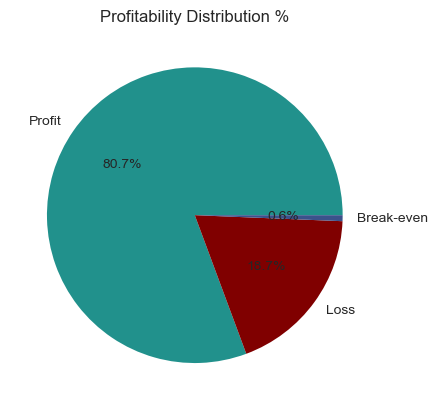

In [24]:
# Visualization of Profitability Flag Distribution
profit_counts=df['Profitability Flag'].value_counts(normalize=True)*100
profit_counts.plot(kind='pie',autopct='%1.1f%%',colors=[accent_color,danger_color,secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution %')
plt.show()
                

In [25]:
def format_func(value):
    if value>=1e6:
        return f'{value/1e6:.1f}M $'
    elif value>=1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

delayed_df=df[df['Delay']>0]
metrics={}
metrics['Total Orders']=len(df)
metrics['Late Deliveries']=len(delayed_df)
metrics['90% Delay (days)']=delayed_df['Delay'].quantile(0.90)
metrics['On Time Delivery %']=(1-float(metrics['Late Deliveries'])/metrics['Total Orders'])*100
metrics['Late Delivery %']=float(metrics['Late Deliveries'])/metrics['Total Orders']*100
metrics['Total Profit']=format_func(df.loc[df['Order Profit Per Order']>0,'Order Profit Per Order'].sum())
metrics['Total Loss due to delays']=format_func(df.loc[df['Delay']>0,'Order Profit Per Order'].sum())

print('\n ----- Business KPIs ----- \n')
for k,v in metrics.items():
    if isinstance(v,float):
        print(f"{k}:{v:.2f}")
    else:
        print(f"{k}:{v}")
        
              
                                    


 ----- Business KPIs ----- 

Total Orders:172765
Late Deliveries:94523
90% Delay (days):3.00
On Time Delivery %:45.29
Late Delivery %:54.71
Total Profit:7.5M $
Total Loss due to delays:2.1M $


### Profitability vs Delivery Time Analysis

In [26]:
profit_metrics=(
    df.groupby('Delay')['Order Profit Per Order'].agg(mean_profit='mean',total_profit='sum',order_count='count').reset_index())

In [27]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [28]:
delay_distribution=(df['Delay'].value_counts(normalize=True).sort_index()*100).reset_index()

In [29]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



 Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



 Delay Distribution(%):


,Delay_days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


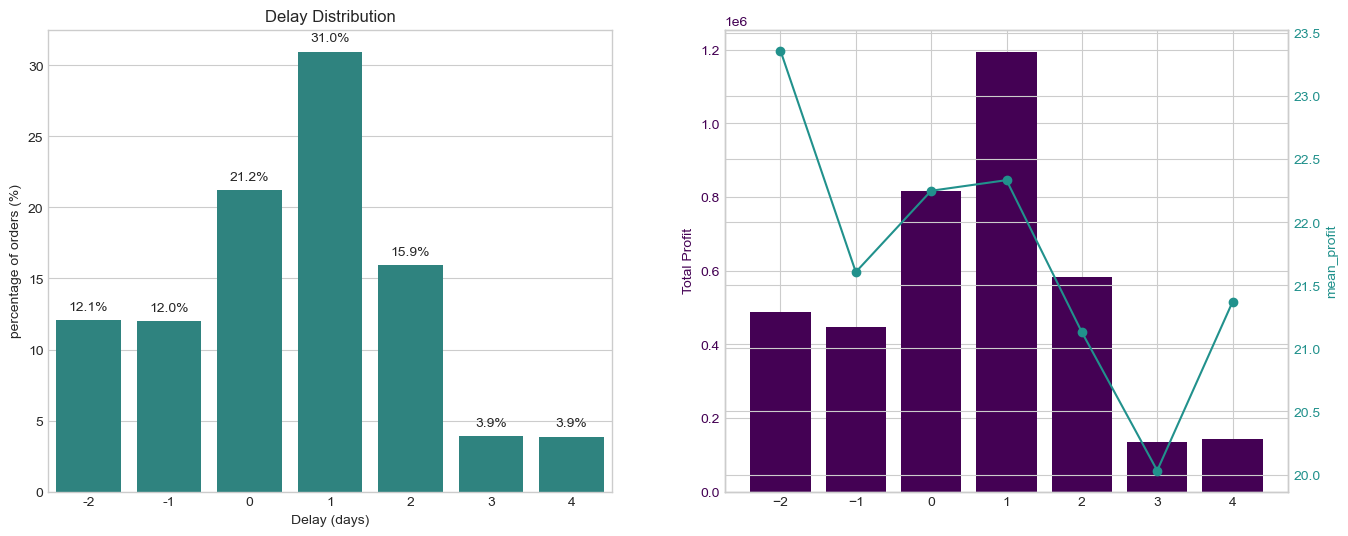

In [30]:
delay_distribution.columns=['Delay_days','Percentage']

print("\n Profit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\n Delay Distribution(%):")
display(delay_distribution)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

# First Subplot: Delay Distribution
sns.barplot(x='Delay_days',y='Percentage',data=delay_distribution,color=accent_color,ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of orders (%)')

# percentage text on bars 
for bar in ax1.patches:
    height=bar.get_height()
    ax1.text(bar.get_x()+bar.get_width()/2,height+0.5,f'{height:.1f}%',ha='center',va='bottom')
    
# Second Subplot : Profit Analysis by Delay Days
ax2.set_ylabel('Total Profit',color=primary_color)
ax2.bar(profit_metrics['Delay'],profit_metrics['total_profit'],color=primary_color,label='Total Profit')
ax2.tick_params(axis='y',labelcolor=primary_color)

ax3=ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("mean_profit",color=accent_color)
ax3.plot(profit_metrics['Delay'],profit_metrics['mean_profit'],marker='o',label='Mean Profit',color=accent_color)
ax3.tick_params(axis='y',labelcolor=accent_color)


## Bottleneck Detection

## Bottleneck Detection

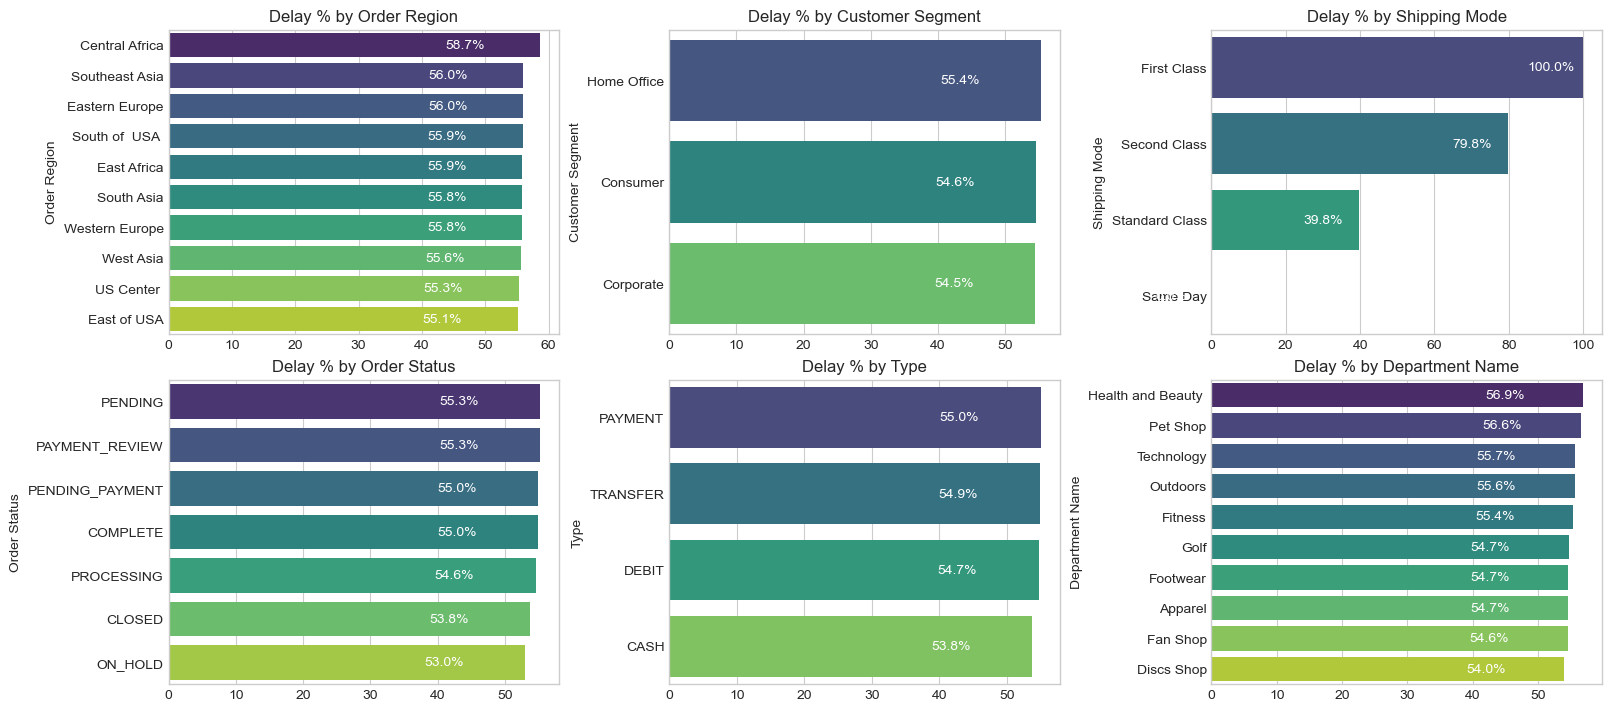

In [31]:
def compute_delay_pct_by_category(category):
    cat_df=df.groupby(category).agg(total_orders=('Delay','count'),late_orders=('is_delayed','sum')).reset_index()
    cat_df['delay_pct']=cat_df['late_orders']/cat_df['total_orders']*100
    cat_df=cat_df.sort_values('delay_pct',ascending=False).head(10)
    return cat_df

categories=['Order Region','Customer Segment','Shipping Mode','Order Status','Type','Department Name']

fig,axes=plt.subplots(2,3,figsize=(16,7),constrained_layout=True)
axes=axes.flatten()

for ax,category in zip(axes,categories):
    cat_df=compute_delay_pct_by_category(category)
    sns.barplot(data=cat_df,x='delay_pct',y=category,ax=ax,palette='viridis')
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i,row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct']-15,i,f"{row['delay_pct']:.1f}%",va='center',fontsize=10,color='white')

plt.show()
    

## Root Cause Analysis

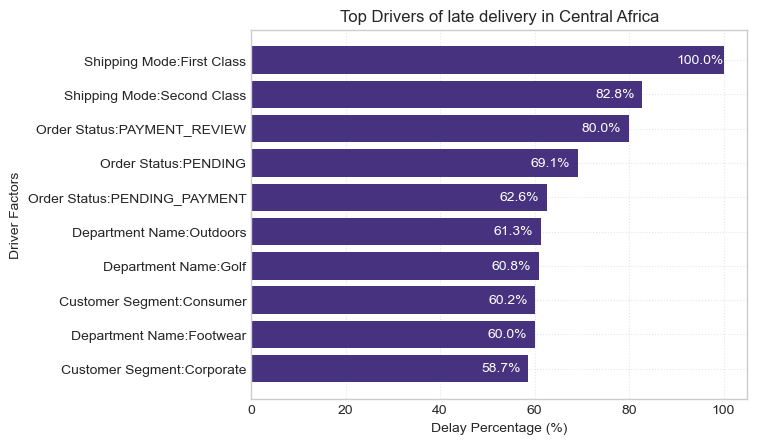

In [32]:
# Top drivers of late delivery by region
def top_drivers_for_region(region):
    df_region=df[df['Order Region']==region].copy()
    drivers=['Shipping Mode','Customer Segment','Department Name','Order Status']

    all_factors=[]

    for factor in drivers:
        temp=df_region.groupby(factor).agg(total_orders=('Delay','count'),
                late_orders=('is_delayed','sum'),avg_delay=('Delay','mean')).reset_index()
        
        temp['delay_pct']=temp['late_orders']/temp['total_orders']*100
        temp['Driver']=factor
        temp['Factor_Level']=factor+ ":" + temp[factor].astype(str)

        all_factors.append(temp[['Driver','Factor_Level','delay_pct','avg_delay','total_orders']])
        
    #combine all drivers
    final_df=pd.concat(all_factors)

    #Top 10 drivers
    top_factors=final_df.sort_values('delay_pct',ascending=False).head(10)
    plt.figure()

    bars=plt.barh(top_factors['Factor_Level'],top_factors['delay_pct'])

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of late delivery in {region}")
    plt.grid(True,linestyle=':',alpha=0.5)
    plt.gca().invert_yaxis()
    for bar in bars:
        width=bar.get_width()
        plt.text(width-10,bar.get_y()+bar.get_height()/2,f"{width:.1f}%",va='center',fontsize=10,color='white')
    plt.show()

top_drivers_for_region('Central Africa')

## Time Based Analysis

In [33]:
# Delay by month,Day of week,hour
delay_by_month=(
    df.groupby('order_month')['is_delayed'].mean().reset_index())
delay_by_month['delay_pct']=delay_by_month['is_delayed']*100

delay_by_day=(df.groupby('order_day')['is_delayed'].mean().reset_index())

delay_by_day['delay_pct']=delay_by_day['is_delayed']*100

delay_by_hour=(df.groupby('order_hour')['is_delayed'].mean().reset_index())

delay_by_hour['delay_pct']=delay_by_hour['is_delayed']*100

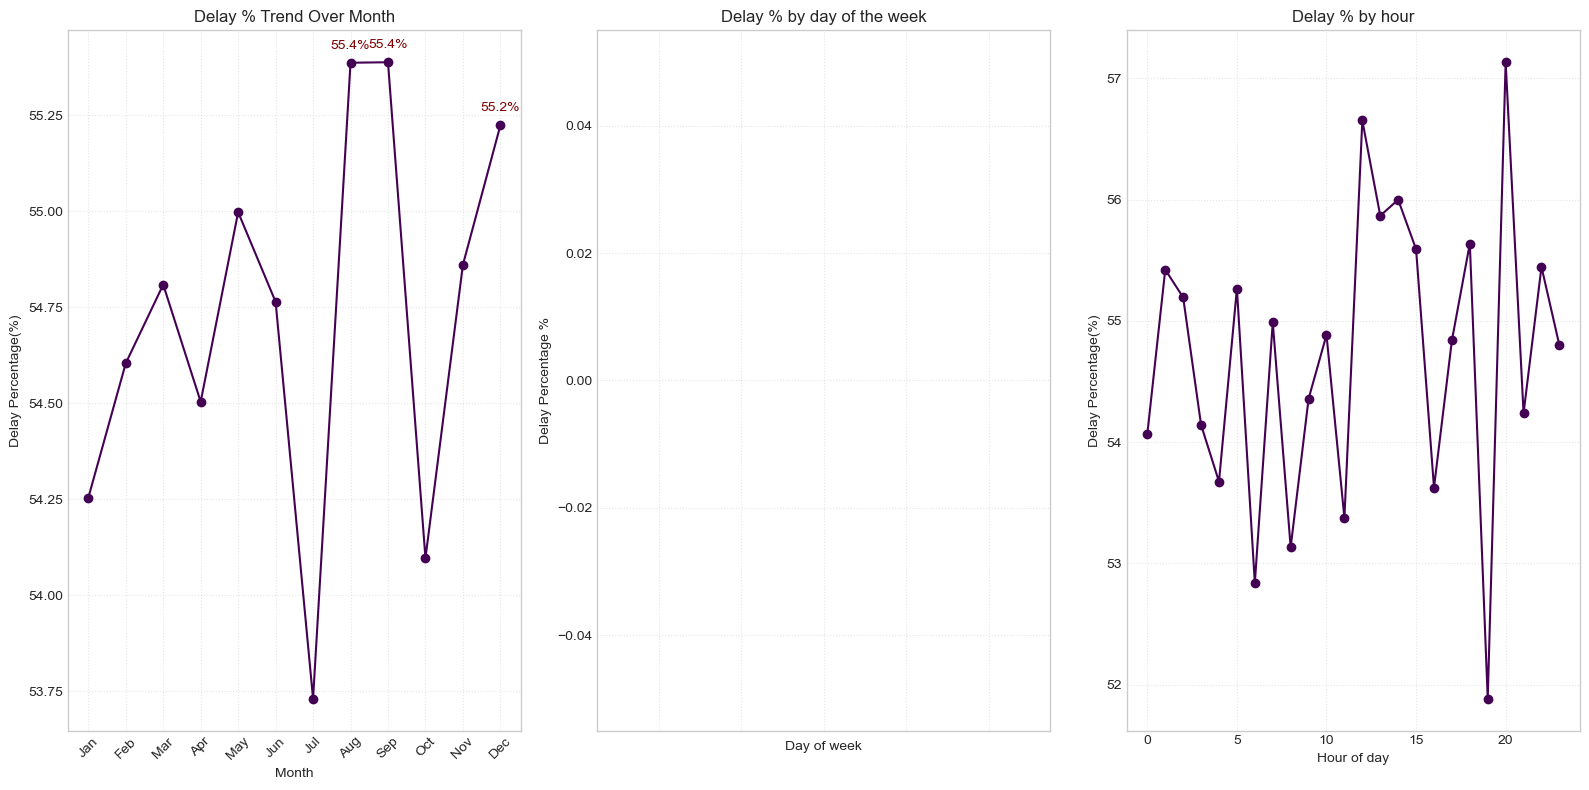

In [34]:
fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(16,8))

# Subplot 1: Delay % Trend over month
ax1.plot(delay_by_month['order_month'],delay_by_month['delay_pct'],marker='o',color=primary_color)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage(%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True,linestyle=":",alpha=0.5)

# Annotate top 3 highest
top3_month=delay_by_month.nlargest(3,'delay_pct')
for _,row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%",(row['order_month'],row['delay_pct']),
                 textcoords="offset points",xytext=(0,10),ha='center',fontsize=10,color=danger_color)

# subplot 2 for delay % by week
day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
delay_by_day['order_day']=pd.Categorical(delay_by_day['order_day'],categories=day_order,ordered=True)
delay_by_day=delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'],delay_by_day['delay_pct'],color=primary_color)
ax2.set_xticklabels(delay_by_day['order_day'],rotation=45)
ax2.set_xlabel("Day of week")
ax2.set_ylabel("Delay Percentage %")
ax2.set_title("Delay % by day of the week")
ax2.grid(True,linestyle=":",alpha=0.5)

# annotate top3 highest bars

top3_day=delay_by_day.nlargest(3,'delay_pct')
for _,row in top3_day.iterrows():
    height=row['delay_pct']
    ax2.text(row['order_day'],height+0.5,f'{height:.1f}%',ha='center',va='bottom',fontsize=10,color=danger_color)
             
# subplot 3: delay by hour
ax3.plot(delay_by_hour['order_hour'],delay_by_hour['delay_pct'],marker='o',color=primary_color)
ax3.set_xlabel("Hour of day")
ax3.set_ylabel("Delay Percentage(%)")
ax3.set_title("Delay % by hour")
ax3.grid(True,linestyle=":",alpha=0.5)

# Annotate top 3 highest

top3_hour=delay_by_hour.nlargest(3,'delay_pct')
for _,row in top3_hour.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%",(row['order_hour'],row['delay_pct']),
                 textcoords="offset points",xytext=(0,10),ha='center',fontsize=10,color=danger_color)

plt.tight_layout()
plt.show()

## Machine Learning Modeling

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [36]:
X=df[['Type','Days for shipment (scheduled)','Category Name','Customer Segment','Department Name','Order Region','Shipping Mode','order_month','order_hour']]
y=df['Late_delivery_risk']

In [37]:
cat_cols=X.select_dtypes(include=['object','category']).columns.tolist()
print("Categorical Columns :",cat_cols)

#frequency encoding (low-dimensional and robust for high cardinality)
for col in cat_cols:
    freq=X[col].value_counts(normalize=True)
    X[f'{col}_freq']=X[col].map(freq)

# keep numerical columns + new encoded features , drop original string categories
X_encoded=X.drop(columns=cat_cols)
print("Shape after freq+target encoding:",X_encoded.shape)

# use encoded features for modeling
X=X_encoded

#train/test split after encoding
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


Categorical Columns : ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after freq+target encoding: (172765, 9)


In [38]:
y.value_counts()

Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

In [39]:
# Balancing the train data using SMOTE
print("Before balancing (train):",Counter(y_train))
smote=SMOTE(random_state=42)
X_train_bal,y_train_bal=smote.fit_resample(X_train,y_train)

print("After balancing (train):",Counter(y_train_bal))

Before balancing (train): Counter({1: 79182, 0: 59030})
After balancing (train): Counter({0: 79182, 1: 79182})


In [40]:
def evaluate_model(y_true,y_pred,model_name):
    print(f"\n -------{model_name}------")
    print("Accuracy:",round(accuracy_score(y_true,y_pred),2))
    print("Precision:",round(precision_score(y_true,y_pred),2))
    print("Recall:",round(recall_score(y_true,y_pred),2))
    print("\nClassification Report:\n",classification_report(y_true,y_pred))
    

In [ ]:
# Fit the Random Forest model on balanced data
rf_model_balanced=RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal,y_train_bal)
y_pred_rf_balanced=rf_model_balanced.predict(X_test)
evaluate_model(y_test,y_pred_rf_balanced,"Random Forest Classifier")

**Summary** 

The analysis covers 172165 orders covering spanning January 2015 through January 2018 , focusing on identifying the root causes of chroninc late deliveries , qunatifying their financial impact,and establishing a data driven framework for improvement.

54.71% of all orders delivered are late,costing the business 2.1M dollars, in eroded profitability on delayed orders alone. While, total profit across fulfilled orders reached $7.5M. A Random Forest predictive model acheived 74% accuracy in identifying at-risk orders before they become late. 

Late delivery rate at 54.71 %  - More than half of all orders arrive late.This is not an edge-case problem.It is a default experience for majority of customers.

90th Percentile delay - 3 days ---> Even the most extreme cases contains the delay within 3 days of lateness, suggesting the problem is systematic, process driven rather than catastrophic.

**Bottleneck detection**
Shipping Mode is no.1 factor: first class: 100 % delay rate, second class :79.8%, standard class: 39.8% , same day : 0%.The mode assignment logic is single important variable to fix.

Regional spread is narrower : central africa is 58.7%, but all regional clusters are between 55-59%.

Customer segments nearly identical : No segment receives preferrential service. all Customers experience broken delivery promise.

Health and Beauty(56.9%), Pet Shop (56.6%) Lead by department : These departments marginally outplace others in delay rate.

**Time Based delay patterns**: 

Peak Delay Months : August and September -- August and September are highest months at 55.4% with december close behind.These reflect mid year promotions and Q4 holiday surge overwhelming fulfillment capacity. July represent a noticable low point (53.75%), confirming seasonable variable is plannable.

Day of week variance is minimal :Monday (55.5%) and Sunday (55.2%) are the peack days, but the spread across the week is less than 1 percentage point.Day of the week is not a meaningful level of operational intervention.

Intra Day peaks Hour 21 (57.1%),Hour 11 (56.7%) and Hour 12 (56%) : Late evening orders have highest delay rates at 57.1%, likely reflecting processing cutoff windows.Midday peaks suggest bottlenecks during peak volume hours.

**Recommendations :**

1. Immediately Audit First Class and Second class Shipping capacity : First Class Shipping has 100 % delay rate and second class 79.8%. These modes operate in complete contradiction to their brand promise.Conduct an immediate Carrier SLA Audit.Until resolved, consider suspending first class or repricing to reflect actual performance.

2. Deploy the predictive alert system : The random forest model is ready for production. Integrate into order management system to flag high-risk orders at confirmation and trigger proactive customer communication and priority handling queues.

3. Resolve Payment Processing Bottlenecks : Orders in PAYMENT_REVIEW and PENDING_PAYMENT has significantly high delay rates.Introduce automated escalation for stalled payments exceeding more than 2 hours.

4. Develop seasonal surge capactiy plans : August, September and Decemeber are peak delay months.Build Pre-season capacity plans including temporary logistics partnerships, inventory-prepositioning and adjusted delivery promise windows.

5. Default to Standard Class for eligible orders : Standard class achieves 39.8% delay rate - far superior to First class and Second Class Shipping Mode.Re-evaluate shipping mode assignment logic to default eligible orders to Standard Class, particularly in departments and regions with poor premium mode performance.

In [ ]:
%